# Laboratorio Segment Anything Model (SAM)

En primer lugar debes haber visto el tutorial de envío del laboratorio. Allí se detalla cómo se deben guardar las respuestas de este laboratorio y enviarlas posteriormente mediante la ventana de envío. Además, debes ingresar tu código uniandes a continuación:

In [2]:
codigo = 201720598 #Código estudiante uniandes

## Revisión general de SAM

El proyecto Segment Anything propuso una tarea general ahora conocida como segmentación indicable. Es decir, dada una imagen y un indicio, se debe producir al menos una máscara válida. En este contexto, un indicio se define como un punto en la imagen, una caja, una máscara o una descripción de texto (experimental).

![promptable_seg](../Lab_3_v2/SAM_workshop_data/imagenes/230575154-2d5410d1-363d-4d70-8949-688991073db5.png)

Siguiendo esta descripción de una tarea, se propone el Módulo Segment Anything (SAM):

![SAM_arch_overview](../Lab_3_v2/SAM_workshop_data/imagenes/Capture-d--cran-2023-04-18---14.13.57.png)

Como puede observar, en caso de que se proporcione una máscara como indicio, se aplican algunas capas convolucionales a dicha máscara, seguidas de la concatenación con las incrustaciones de la imagen. De lo contrario, si se proporcionan puntos, cajas o indicios de texto, un codificador alimenta el decodificador final que siempre producirá las máscaras deseadas.

Meta ha proporcionado una demostración públicamente disponible con la que los usuarios pueden jugar en un conjunto de imágenes predefinido. Lo invitamos a visitar [su sitio web de demostración oficial](https://segment-anything.com/demo) y probar las formas estándar de indicar a SAM y visualizar sus capacidades.

En este laboratorio aprenderemos a usar el **generador automático de máscaras** de SAM. Este generador automático introduce una malla de puntos como indicio al modelo, lo que deriva en la generación de las máscaras de segmentación. Además, exploraremos cómo los **parámetros del generador automático** afectan el desempeño del modelo. 

Primero importemos las librerías necesarias para este laboratorio:

In [4]:
#Librerías 
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import os
import lm
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from lvis.lvis import LVIS
import pycocotools.mask as mask_utils
import datetime
import numpy as np
from tqdm import tqdm
from lvis import LVIS, LVISVis, LVISResults, LVISEval
import os
import random

data_path = os.path.join('..', 'Lab_3_v2', 'SAM_workshop_data')

Además, creemos algunas funciones auxiliares que vamos a usar dentro del laboratorio

In [5]:
#Función para visualizar anotaciones
def mostrar_anotaciones(anotaciones):
    if len(anotaciones) == 0:
        return
    # Ordenar las anotaciones por área en orden descendente
    anotaciones_ordenadas = sorted(anotaciones, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    # Crear una imagen en blanco con una canal alfa para la transparencia
    img = np.ones((anotaciones_ordenadas[0]['segmentation'].shape[0], anotaciones_ordenadas[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0  # Establecer el canal alfa a 0 (totalmente transparente)
    for anotacion in anotaciones_ordenadas:
        m = anotacion['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])  # Generar un color aleatorio con una transparencia del 35%
        img[m] = color_mask
    ax.imshow(img)  # Mostrar la imagen con las máscaras de color


#Función empleada para determinar las métricas de evaluación
def no_cat_summarize(lvis_evaluator):
        """Compute and display summary metrics for evaluation results."""
        if not lvis_evaluator.eval:
            raise RuntimeError("Please run accumulate() first.")

        max_dets = lvis_evaluator.params.max_dets

        lvis_evaluator.results["AP"]   = lvis_evaluator._summarize('ap')
        lvis_evaluator.results["AP50"] = lvis_evaluator._summarize('ap', iou_thr=0.50)
        lvis_evaluator.results["AP75"] = lvis_evaluator._summarize('ap', iou_thr=0.75)
        lvis_evaluator.results["APs"]  = lvis_evaluator._summarize('ap', area_rng="small")
        lvis_evaluator.results["APm"]  = lvis_evaluator._summarize('ap', area_rng="medium")
        lvis_evaluator.results["APl"]  = lvis_evaluator._summarize('ap', area_rng="large")

        key = "AR@{}".format(max_dets)
        lvis_evaluator.results[key] = lvis_evaluator._summarize('ar')

        for area_rng in ["small", "medium", "large"]:
            key = "AR{}@{}".format(area_rng[0], max_dets)
            lvis_evaluator.results[key] = lvis_evaluator._summarize('ar', area_rng=area_rng)


#Corrección para las métricas
def no_np_float_accumulate(lvis_evaluator):
    """Accumulate per image evaluation results and store the result in
    lvis_evaluator.eval.
    """
    lvis_evaluator.logger.info("Accumulating evaluation results.")

    if not lvis_evaluator.eval_imgs:
        lvis_evaluator.logger.warn("Please run evaluate first.")

    if lvis_evaluator.params.use_cats:
        cat_ids = lvis_evaluator.params.cat_ids
    else:
        cat_ids = [-1]

    num_thrs = len(lvis_evaluator.params.iou_thrs)
    num_recalls = len(lvis_evaluator.params.rec_thrs)
    num_cats = len(cat_ids)
    num_area_rngs = len(lvis_evaluator.params.area_rng)
    num_imgs = len(lvis_evaluator.params.img_ids)

    # -1 for absent categories
    precision = -np.ones(
        (num_thrs, num_recalls, num_cats, num_area_rngs)
    )
    recall = -np.ones((num_thrs, num_cats, num_area_rngs))

    # Initialize dt_pointers
    dt_pointers = {}
    for cat_idx in range(num_cats):
        dt_pointers[cat_idx] = {}
        for area_idx in range(num_area_rngs):
            dt_pointers[cat_idx][area_idx] = {}

    # Per category evaluation
    for cat_idx in range(num_cats):
        Nk = cat_idx * num_area_rngs * num_imgs
        for area_idx in range(num_area_rngs):
            Na = area_idx * num_imgs
            E = [
                lvis_evaluator.eval_imgs[Nk + Na + img_idx]
                for img_idx in range(num_imgs)
            ]
            # Remove elements which are None
            E = [e for e in E if not e is None]
            if len(E) == 0:
                continue

            # Append all scores: shape (N,)
            dt_scores = np.concatenate([e["dt_scores"] for e in E], axis=0)
            dt_ids = np.concatenate([e["dt_ids"] for e in E], axis=0)

            dt_idx = np.argsort(-dt_scores, kind="mergesort")
            dt_scores = dt_scores[dt_idx]
            dt_ids = dt_ids[dt_idx]

            dt_m = np.concatenate([e["dt_matches"] for e in E], axis=1)[:, dt_idx]
            dt_ig = np.concatenate([e["dt_ignore"] for e in E], axis=1)[:, dt_idx]

            gt_ig = np.concatenate([e["gt_ignore"] for e in E])
            # num gt anns to consider
            num_gt = np.count_nonzero(gt_ig == 0)

            if num_gt == 0:
                continue

            tps = np.logical_and(dt_m, np.logical_not(dt_ig))
            fps = np.logical_and(np.logical_not(dt_m), np.logical_not(dt_ig))

            tp_sum = np.cumsum(tps, axis=1).astype(dtype=float)
            fp_sum = np.cumsum(fps, axis=1).astype(dtype=float)

            dt_pointers[cat_idx][area_idx] = {
                "dt_ids": dt_ids,
                "tps": tps,
                "fps": fps,
            }

            for iou_thr_idx, (tp, fp) in enumerate(zip(tp_sum, fp_sum)):
                tp = np.array(tp)
                fp = np.array(fp)
                num_tp = len(tp)
                rc = tp / num_gt
                if num_tp:
                    recall[iou_thr_idx, cat_idx, area_idx] = rc[
                        -1
                    ]
                else:
                    recall[iou_thr_idx, cat_idx, area_idx] = 0

                # np.spacing(1) ~= eps
                pr = tp / (fp + tp + np.spacing(1))
                pr = pr.tolist()

                # Replace each precision value with the maximum precision
                # value to the right of that recall level. This ensures
                # that the  calculated AP value will be less suspectable
                # to small variations in the ranking.
                for i in range(num_tp - 1, 0, -1):
                    if pr[i] > pr[i - 1]:
                        pr[i - 1] = pr[i]

                rec_thrs_insert_idx = np.searchsorted(
                    rc, lvis_evaluator.params.rec_thrs, side="left"
                )

                pr_at_recall = [0.0] * num_recalls

                try:
                    for _idx, pr_idx in enumerate(rec_thrs_insert_idx):
                        pr_at_recall[_idx] = pr[pr_idx]
                except:
                    pass
                precision[iou_thr_idx, :, cat_idx, area_idx] = np.array(pr_at_recall)

    lvis_evaluator.eval = {
        "params": lvis_evaluator.params,
        "counts": [num_thrs, num_recalls, num_cats, num_area_rngs],
        "date": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "precision": precision,
        "recall": recall,
        "dt_pointers": dt_pointers,
    }


#Función para determinar la cantidad de máscaras propuestas por imagen
def propuestas_por_imagen(lvis_sam_results):
    # Obtener los IDs de las imágenes evaluadas
    img_ids_a_evaluar = set()
    for resultado in lvis_sam_results.dataset["annotations"]:
        img_ids_a_evaluar.add(resultado['image_id'])
    print(f"ID's de las imágenes evaluadas: {img_ids_a_evaluar}")

    # Contar el número de propuestas de máscara por imagen hechas por SAM
    numero_de_propuestas_de_mascara_por_imagen_por_SAM = []
    for image_id in img_ids_a_evaluar:
        numero_de_propuestas_de_mascara_por_imagen_por_SAM.append(len(lvis_sam_results.get_ann_ids(img_ids=[image_id])))
    print(f"numero_de_propuestas_de_mascara_por_imagen_por_SAM: {numero_de_propuestas_de_mascara_por_imagen_por_SAM}")
    print(f"promedio_de_propuestas_de_mascara_por_imagen_por_SAM: {sum(numero_de_propuestas_de_mascara_por_imagen_por_SAM)/len(numero_de_propuestas_de_mascara_por_imagen_por_SAM)}")



Por último fijemos la semilla del entorno para que los resultados obtenidos sean reproducibles

In [6]:
# Asegura que los resultados sean replicables
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Fijar la semilla
set_seed(42)

## Generación automática de máscaras de objetos con SAM

Dado que SAM puede procesar eficientemente indicios, se pueden generar máscaras para toda la imagen 
muestreando un gran número de estos. La clase `SamAutomaticMaskGenerator` implementa esta capacidad y 
funciona muestreando indicios de entrada a partir de una cuadrícula establecida sobre la imagen. Teniendo 
en cuenta estos indicios, SAM puede predecir múltiples máscaras. Luego, las máscaras se filtran por calidad y se eliminan duplicados utilizando supresión de no máximos. Opciones adicionales permiten una mayor mejora de la calidad y cantidad de las máscaras, como ejecutar predicciones en múltiples recortes de la imagen o postprocesar las máscaras para eliminar pequeñas regiones desconectadas y agujeros.

Para usar la generación automática de máscaras, primero debemos cargar el modelo preentrenado: 

In [7]:
# Establecer la ruta a los parámetros guardados y el tipo de modelo
sam_checkpoint = os.path.join(data_path, 'sam_vit_h_4b8939.pth')
model_type = "vit_h"

# Definir el dispositivo (CUDA)
device = "cuda:0"

# Cargar el modelo SAM del registro y moverlo al dispositivo especificado
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1280, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-31): 32 x Block(
        (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1280, out_features=3840, bias=True)
          (proj): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=1280, out_features=5120, bias=True)
          (lin2): Linear(in_features=5120, out_features=1280, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(1280, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d

Una vez cargado el modelo, podemos definir nuestro **generador automático de máscaras** haciendo uso de la clase `SamAutomaticMaskGenerator`. Es importante mencionar que esta clase tiene varios parámetros modificables que exploraremos posteriormente.

In [8]:
mask_generator = SamAutomaticMaskGenerator(sam)

### Ejemplo 1: segmentando una imagen

Primero cargamos y visualizamos la imagen a partir de la cuál generaremos las máscaras:

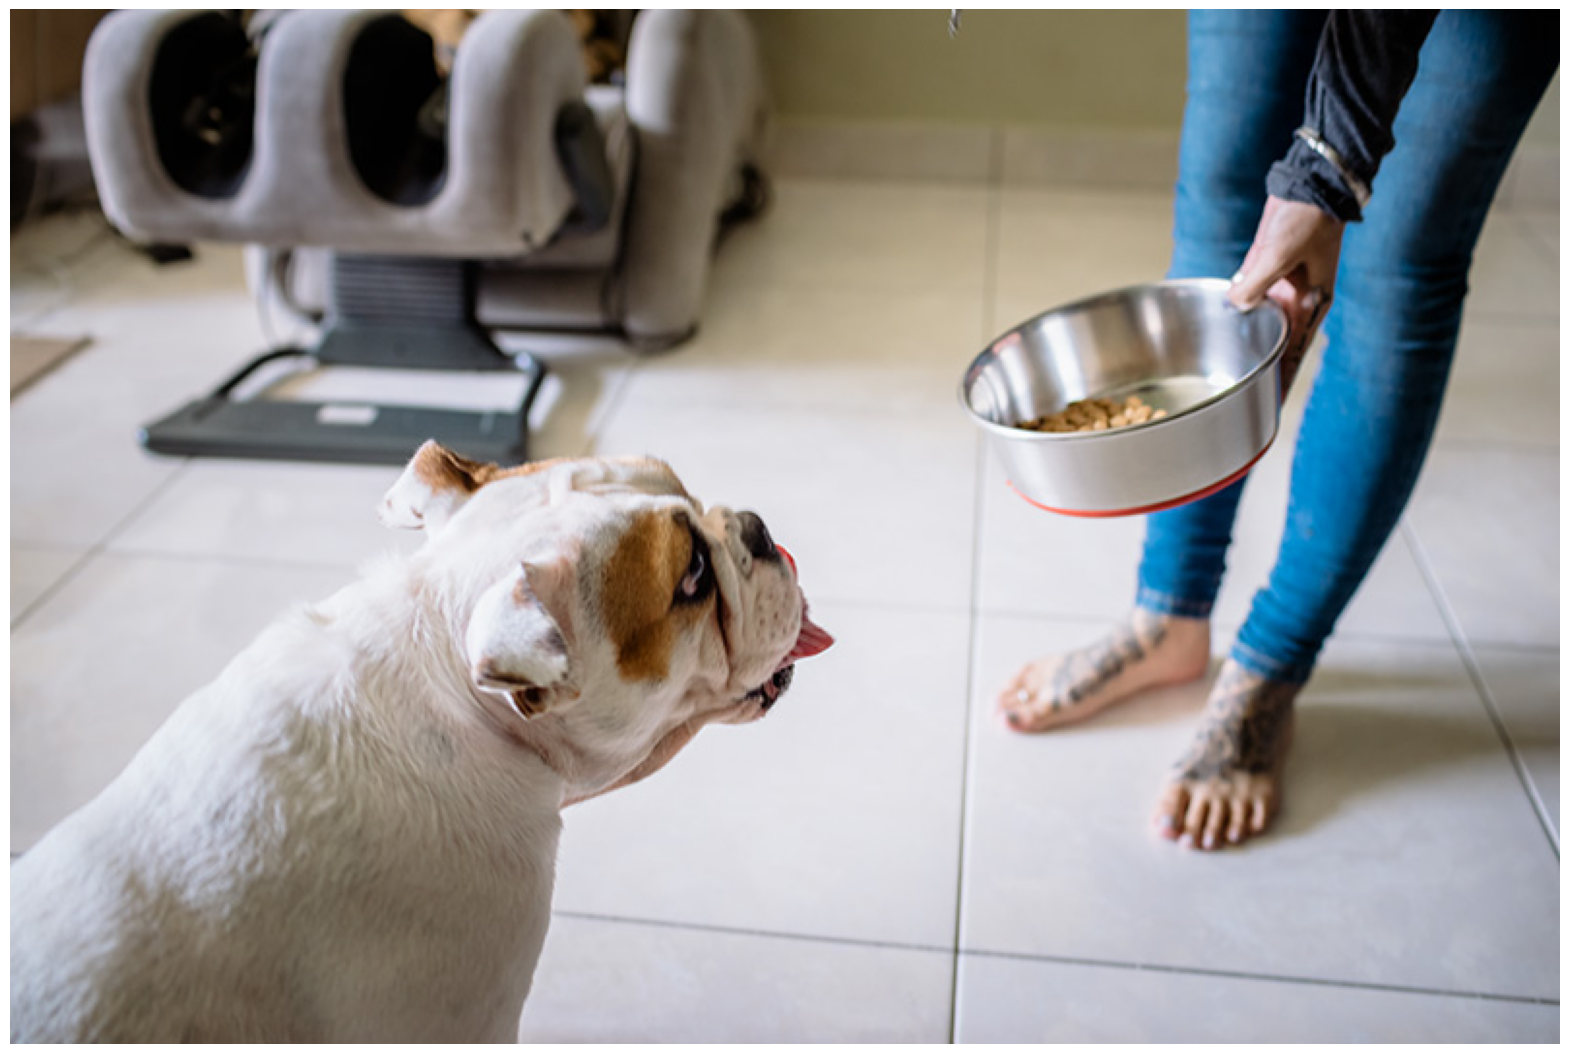

In [9]:
imagen = cv2.imread(os.path.join(data_path, 'imagenes', 'dog.jpg'))
imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20,20))
plt.imshow(imagen)
plt.axis('off')
plt.show()

Para generar máscaras, se ejecuta `generate` en la imagen.

In [10]:
masks = mask_generator.generate(imagen)

A continuación visualicemos las máscaras predichas:

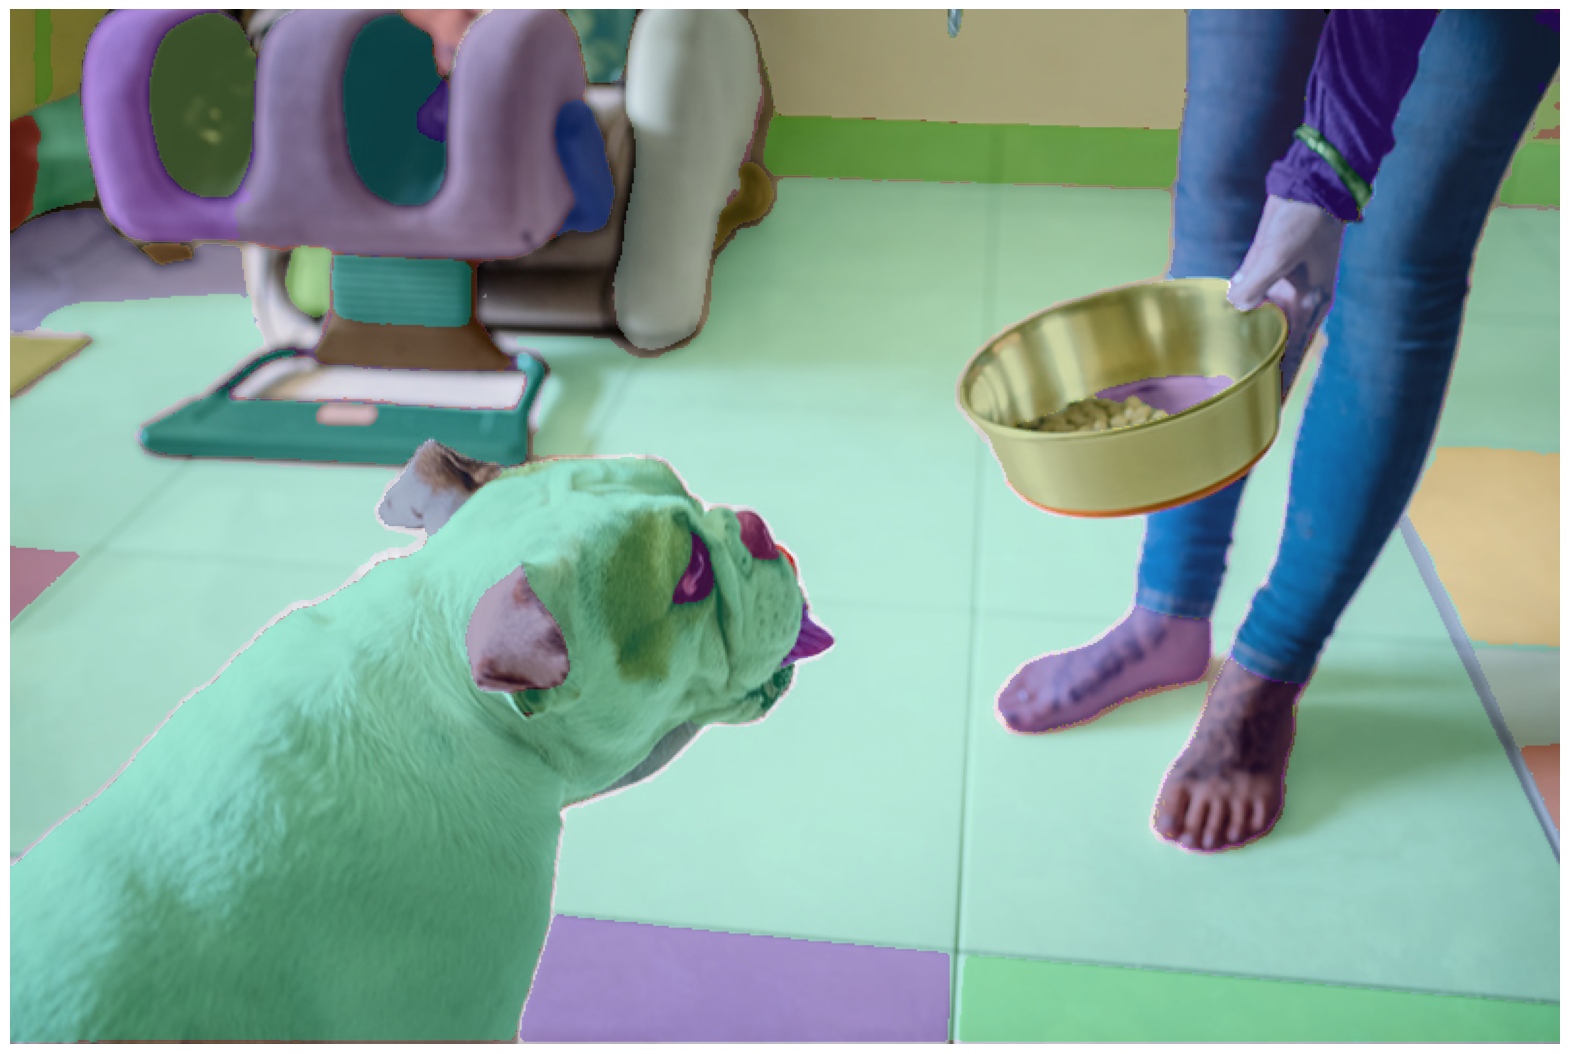

In [11]:
plt.figure(figsize=(20,20))
plt.imshow(imagen)
mostrar_anotaciones(masks)
plt.axis('off')
plt.show()

Además, veamos cuántas máscaras predijo el modelo y el formato asociado a las mismas:

In [12]:
print(len(masks))
print(masks[0].keys())

66
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


La generación de máscaras devuelve una lista de máscaras, donde cada máscara es un diccionario que contiene varios datos sobre la máscara. Estos datos son:
* `segmentation` : la máscara
* `area` : el área de la máscara en píxeles
* `bbox` : la caja delimitadora de la máscara en formato XYWH
* `predicted_iou` : la propia predicción del modelo sobre la calidad de la máscara
* `point_coords` : el punto de entrada muestreado que generó esta máscara
* `stability_score` : una medida adicional de la calidad de la máscara
* `crop_box` : el recorte de la imagen utilizado para generar esta máscara en formato XYWH

## Desempeño de SAM en la tarea

Ahora que ya entendemos cómo funciona la generación de máscaras automática, recrearemos a menor escala el proceso realizado por los autores originales de Segment Anything para hacer propuestas de objetos sin entrenamiento previo. Para ello, emplearemos el [conjunto de datos lvis](https://www.lvisdataset.org/dataset), sobre el cual evaluaremos las propuestas del modelo. Es importante mencionar que el proceso que vamos a replicar se describe a detalle en el [artículo original](https://arxiv.org/pdf/2304.02643).

Dado que vamos a evaluar el modelo, necesitamos cargar las anotaciones. En este caso cargaremos las anotaciones las imágenes del conjunto de validación. Además, para facilitar la visualización y los cálculos de las métricas, emplearemos una instancia de anotaciones de lvis. 

In [13]:
# Archivos de resultados y validación para 100 imágenes muestreadas aleatoriamente.
annotation_path = os.path.join(data_path,'lvis_dataset/lvis_v1_val.json')

# Crear una instancia de anotaciones de LVIS
lvis_annotation = LVIS(annotation_path)

# Establecer el directorio con las imagenes
img_dir = os.path.join(data_path, 'lvis_dataset', 'val2017')

# Crear otra instancia para visualización y un visualizer
lvis_annotation_for_visualization = LVIS(annotation_path)
lvis_annotation_visualizer = LVISVis(lvis_annotation_for_visualization, img_dir=img_dir, dpi=300)

### Ejemplo 2: cargando y segmentando una imagen de lvis

Ahora veamos cómo se puede emplear la instancia lvis para generar máscaras de una imagen de este dataset. Para ello, carguemos una imagen, generemos sus máscaras y visualicemos el resultado.

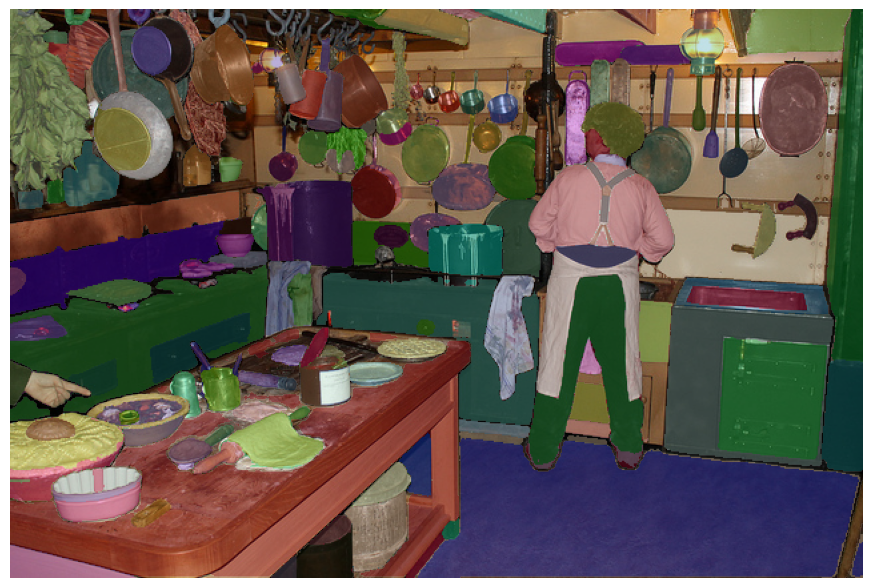

In [14]:
#Ejemplo con un id
one_id = 397133

#obtenemos el nombre del archivo
nombre_archivo = lvis_annotation.load_imgs([one_id])[0]['coco_url'].split('/')[-1]

#cargamos la imagen
imagen = cv2.imread(os.path.join(img_dir, nombre_archivo))
imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

#obtenemos las máscaras
mascaras = mask_generator.generate(imagen)

#visualizamos el resultado
plt.figure(figsize=(11,11))
plt.imshow(imagen)
mostrar_anotaciones(mascaras)
plt.axis('off')
plt.show()


Ahora visualicemos la anotación de la imagen:

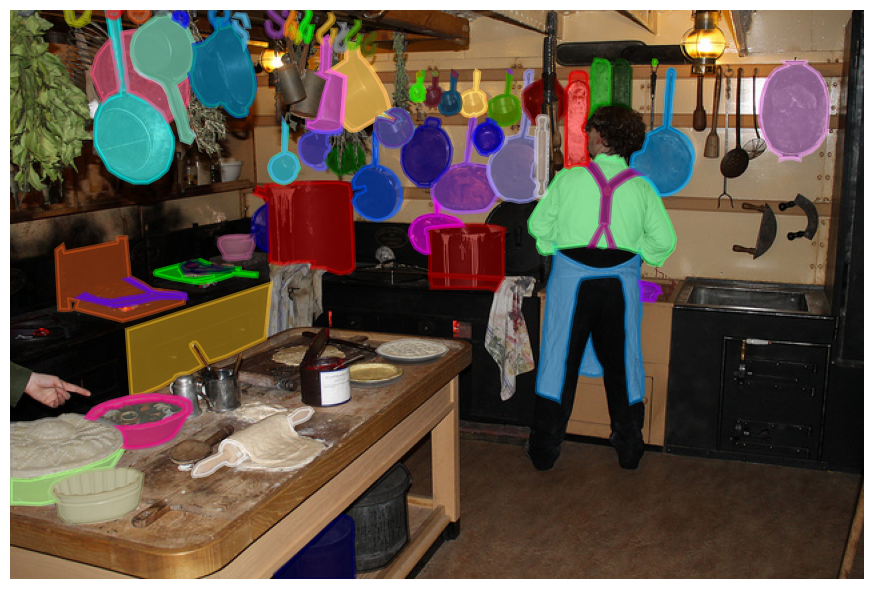

In [15]:
lvis_annotation_visualizer.vis_img(one_id)

Como era de esperar, SAM produce muchas más máscaras propuestas de las que hay anotadas en la imagen. Sin embargo, para la tarea en cuestión se reporta el Recall Promedio@1000. Es decir, se toman las mejores 1000 propuestas de SAM por imagen y se calcula el recall promedio de las máscaras. En ese sentido, la precisión no es parte del alcance de nuestra tarea, ya que estamos midiendo la capacidad de SAM para detectar las máscaras que estan anotadas.

Por consiguiente, la siguiente celda eliminará la variabilidad de categorías en las anotaciones, de modo que todas las predicciones se puedan hacer con una sola categoría. De esta manera, podremos calcular las métricas y evaluar el Recall promedio del modelo. 

In [16]:
# Establecer todas las anotaciones a una sola categoría
for anotacion in lvis_annotation.dataset['annotations']:
    anotacion['category_id'] = 1

# Eliminar categoría negativa si existe
for imagen in lvis_annotation.dataset['images']:
    try:
        imagen['neg_category_ids'].remove(1)
    except:
        pass

# Crear el índice actualizado
lvis_annotation._create_index()

# Trabajo Grupal

## Funciones de extracción de máscaras

Ahora que vimos una introducción general a lvis, tu tarea será continuar con la evaluación del generador de máscaras y explorar cómo influyen algunos parámetros en el desempeño del mismo. Para ello, primero debemos crear una función que extraiga las máscaras a partir del nombre de una imagen `image_name` y un generador de máscaras `M_generator`. Por favor completa las líneas faltantes en la siguiente función:

In [31]:
def img2masks(image_name, M_generator):
    data_path = os.path.join('..', 'Lab_3_v2', 'SAM_workshop_data')
    img_dir = os.path.join(data_path, 'lvis_dataset', 'val2017')
    #COMPLETA DESDE AQUI
    imagen = cv2.cvtColor(cv2.imread(os.path.join(img_dir,image_name)), cv2.COLOR_BGR2RGB)
    masks = M_generator.generate(imagen)
    #COMPLETA HASTA AQUI
    return masks

### verifica y guarda tu respuesta 1

In [32]:
#Pruebas
z = None
try:
    nombre_prueba = '000000397133.jpg'
    z = img2masks(nombre_prueba, mask_generator)
except:
    print('Errores de implementación')
assert type(z) == list, 'Errores de implementación,'
assert len(z) > 0, 'Errores de implementación'
assert type(z[0]) == dict, 'Errores de implementación'
#Guardado
lm.verify_and_save(1, z, codigo)


Una vez definida la función anterior, podemos crear otra función que, a partir de una lista de ids de imágenes `img_ids` y un generador de máscaras `M_generator`, obtenga las máscaras asociadas a las mismas y las almacene en el formato correcto de evaluación. Por favor completa las líneas faltantes en la siguiente función:

In [35]:
def ids2results(img_ids, M_generator, lvis_annotation):
    # Iterar sobre los ids de las imágenes
    resultados = []
    for img_id in tqdm(img_ids):
        #COMPLETA DESDE AQUI
        nombre_archivo = lvis_annotation.load_imgs([img_id])[0]['coco_url'].split('/')[-1]
        mascaras = img2masks(nombre_archivo , M_generator) #aqui usa la función img2masks
        #COMPLETA HASTA AQUI
        for mascara in mascaras:
            mascara['segmentation'] = mask_utils.encode(np.asfortranarray(mascara['segmentation']))
            resultados.append({
                'id': id,
                'image_id': img_id,
                'category_id': 1,
                'segmentation': mascara['segmentation'],
                'area': mascara['area'],
                'bbox': mascara['bbox'],
                'score': mascara['stability_score']
            })
    lvis_sam_results = LVISResults(lvis_annotation, resultados)
    return lvis_sam_results

### verifica y guarda tu respuesta 2

In [36]:
#Pruebas
res = None
try:
    Ids_prueba = [331352, 37777]
    res = ids2results(Ids_prueba, mask_generator, lvis_annotation)
except:
    print('Errores de implementación')
assert type(res) == LVISResults, 'Errores de implementación'
assert len(res.dataset['annotations']) > 0, 'Errores de implementación'

#Guardado
lm.verify_and_save(2, res, codigo)


100%|██████████| 2/2 [00:07<00:00,  3.98s/it]
[03/09 23:37:42] lvis.results WARNING: Assuming user provided the results in correct format.


## Evaluación de los resultados

Primero definamos una función de evaluación que calcule las métricas a partir de los resultados obtenidos:

In [37]:
def evaluate_results(lvis_annotation, lvis_sam_results):
    lvis_evaluator = LVISEval(lvis_annotation, lvis_sam_results)
    img_ids_a_evaluar = set()
    for resultado in lvis_sam_results.dataset["annotations"]:
        img_ids_a_evaluar.add(resultado['image_id'])
    lvis_evaluator.params.use_cats = 1
    lvis_evaluator.params.cat_ids = [1]
    lvis_evaluator.params.img_ids = sorted(list(img_ids_a_evaluar))
    lvis_evaluator.evaluate()
    no_np_float_accumulate(lvis_evaluator)
    no_cat_summarize(lvis_evaluator)
    max_dets = lvis_evaluator.params.max_dets
    ar_all = lvis_evaluator._summarize('ar', area_rng = 'all')
    ar_small = lvis_evaluator._summarize('ar', area_rng = 'small')
    ar_medium = lvis_evaluator._summarize('ar', area_rng = 'medium')
    ar_large = lvis_evaluator._summarize('ar', area_rng = 'large')
    return ar_all, ar_small, ar_medium, ar_large, max_dets

Una vez hecho esto, podemos proceder a evaluar el desempeño del generador automático de máscaras en un subconjunto de 10 imágenes

In [38]:
#Ids de las imágenes a evaluar
img_ids = [397133, 37777, 252219, 87038, 174482, 403385, 6818, 480985, 331352, 296649]
results = ids2results(img_ids, mask_generator, lvis_annotation)

100%|██████████| 10/10 [00:40<00:00,  4.03s/it]
[03/09 23:39:12] lvis.results WARNING: Assuming user provided the results in correct format.


In [39]:
ar_all, ar_small, ar_med, ar_large, max_dets = evaluate_results(lvis_annotation, results)
print('Average Recall values')
print('AR@{}'.format(max_dets), 'area = all |', ar_all)
print('AR@{}'.format(max_dets), 'area = small |', ar_small)
print('AR@{}'.format(max_dets), 'area = medium |', ar_med)
print('AR@{}'.format(max_dets), 'area = large |', ar_large)

Average Recall values
AR@300 area = all | 0.572361809045226
AR@300 area = small | 0.4553846153846154
AR@300 area = medium | 0.7761904761904762
AR@300 area = large | 0.9666666666666666


Como puedes observar, hasta ahora únicamente hemos calculado el Recall@300 en lugar de Recall@1000. Además, no hemos modificado los parámetros del generador automático de máscaras para visualizar su influencia en las métricas. En ese sentido, veamos primero cuántas máscaras esta generando SAM para cada imagen: 

In [40]:
propuestas_por_imagen(results)

ID's de las imágenes evaluadas: {6818, 296649, 397133, 37777, 174482, 480985, 331352, 403385, 252219, 87038}
numero_de_propuestas_de_mascara_por_imagen_por_SAM: [77, 237, 198, 108, 139, 156, 57, 118, 156, 123]
promedio_de_propuestas_de_mascara_por_imagen_por_SAM: 136.9


En este caso, las propuestas de SAM no se acercan a las 300. Además, si quisieramos usar el Recall@1000 deberíamos tener un número de propuestas mucho más cercano a 1000. Teniendo esto en cuenta, veamos cómo podemos modificar los parámetros del generador de máscaras para mejorar las métricas y aumentar las propuestas.

## Modificación de parámetros del generador

Los parámetros que se pueden modificar en el generador son:

* points_per_side
* pred_iou_thresh
* stability_score_thresh
* box_nms_thresh
* crop_n_layers
* min_mask_region_area


## Generador de máscaras modificado 1

Investiga acerca de la función de cada uno de los parámetros mencionados dentro de el generador para que entiendas cómo pueden afectar estas modificaciones al mismo. Una vez hecho esto, declara un generador con 40 points per side, pred iou thresh de 0, stability score thresh de 0 y box non maximum suppression thresh de 0.9. **Pista**: para saber cómo se declaran estos parámetros, guíate por el siguiente [tutorial](https://colab.research.google.com/github/facebookresearch/segment-anything/blob/main/notebooks/automatic_mask_generator_example.ipynb).

In [41]:
#COMPLETA DESDE AQUÍ
mod_mask_generator_1 = SamAutomaticMaskGenerator(model = sam , 
                                                points_per_side = 40,
                                                pred_iou_thresh=0,
                                                stability_score_thresh=0,
                                                box_nms_thresh = 0.9)
#COMPLETA HASTA AQUÍ

### verifica y guarda tu respuesta 3

In [42]:
#Pruebas
assert type(mod_mask_generator_1) == SamAutomaticMaskGenerator, 'Errores de implementación'
#Guardado
lm.verify_and_save(3, mod_mask_generator_1, codigo)

Ahora obten los resultados del primer generador modificado a partir de los img_ids declarados anteriormente. Es importante mencionar que en este caso seguiremos calculando el AR@300 por motivos de costo computacional.

In [43]:
#COMPLETA DESDE AQUI
results = ids2results(img_ids, mod_mask_generator_1, lvis_annotation)
#COMPLETA HASTA AQUI

100%|██████████| 10/10 [01:13<00:00,  7.32s/it]
[03/09 23:46:32] lvis.results WARNING: Assuming user provided the results in correct format.


### verifica y guarda tu respuesta 4

In [44]:
#Pruebas
assert type(results) == LVISResults, 'Errores de implementación'
assert len(results.dataset['annotations']) > 0, 'Errores de implementación'
#Guardado
lm.verify_and_save(4, results, codigo)

Finalmente, calcula los valores de AR@300 de los resultados obtenidos:

In [45]:
#COMPLETA DESDE AQUÍ
ar_all, ar_small, ar_med, ar_large, max_dets = evaluate_results(lvis_annotation, results)
#COMPLETA HASTA AQUI

### verifica y guarda tu respuesta 5

In [46]:
#Pruebas
assert ar_all < 1 and ar_all > 0, 'Errores de implementación'
assert ar_small < 1 and ar_small > 0, 'Errores de implementación'
assert ar_med < 1 and ar_med > 0, 'Errores de implementación'
assert ar_large < 1 and ar_large > 0, 'Errores de implementación'
#Guardado   
lm.verify_and_save(5, (ar_all, ar_small, ar_med, ar_large, max_dets), codigo)

Veamos estos valores y la cantidad de propuestas promedio por imagen

In [47]:
print('Average Recall values')
print('AR@{}'.format(max_dets), 'area = all |', ar_all)
print('AR@{}'.format(max_dets), 'area = small |', ar_small)
print('AR@{}'.format(max_dets), 'area = medium |', ar_med)
print('AR@{}'.format(max_dets), 'area = large |', ar_large)
propuestas_por_imagen(results)

Average Recall values
AR@300 area = all | 0.6266331658291457
AR@300 area = small | 0.52
AR@300 area = medium | 0.8142857142857144
AR@300 area = large | 0.9666666666666666
ID's de las imágenes evaluadas: {6818, 296649, 397133, 37777, 174482, 480985, 331352, 403385, 252219, 87038}
numero_de_propuestas_de_mascara_por_imagen_por_SAM: [300, 300, 300, 300, 300, 300, 284, 300, 300, 300]
promedio_de_propuestas_de_mascara_por_imagen_por_SAM: 298.4


Ahora las métricas aumentaron y la cantidad de propuestas de máscaras por imagen es 300 en la mayoría del conjunto evaluado.

## Generador de máscaras modificado 2

Ahora vamos a crear otro generador de máscaras con parámetros diferentes y a evaluar su desempeño. Para este segundo caso, declara un generador con 16 points per side, pred iou thresh de 0.2, stability score thresh de 0.1 y box non maximum suppression thresh de 0.4, crop n layers de 1 y min mask region area de 100. 

In [48]:
#COMPLETA DESDE AQUÍ
mod_mask_generator_2 = SamAutomaticMaskGenerator(model = sam , 
                                                points_per_side = 16,
                                                pred_iou_thresh=0.2,
                                                stability_score_thresh=0.1,
                                                box_nms_thresh = 0.4,
                                                crop_n_layers=1,
                                                min_mask_region_area=100)
#COMPLETA HASTA AQUÍ

### verifica y guarda tu respuesta 6

In [49]:
#Pruebas
assert type(mod_mask_generator_2) == SamAutomaticMaskGenerator, 'Errores de implementación'
#Guardado
lm.verify_and_save(6, mod_mask_generator_2, codigo)

Ahora obten los resultados del segundo generador modificado a partir de los img_ids declarados anteriormente.

In [50]:
#COMPLETA DESDE AQUI
results = ids2results(img_ids, mod_mask_generator_2, lvis_annotation)
#COMPLETA HASTA AQUI

100%|██████████| 10/10 [01:48<00:00, 10.85s/it]
[03/09 23:51:28] lvis.results WARNING: Assuming user provided the results in correct format.


### verifica y guarda tu respuesta 7

In [51]:
#Pruebas
assert type(results) == LVISResults, 'Errores de implementación'
assert len(results.dataset['annotations']) > 0, 'Errores de implementación'
#Guardado
lm.verify_and_save(7, results, codigo)

Por último, calcula los valores de AR@300 de los resultados obtenidos:

In [52]:
#COMPLETA DESDE AQUÍ
ar_all, ar_small, ar_med, ar_large, max_dets = evaluate_results(lvis_annotation, results)
#COMPLETA HASTA AQUI

### verifica y guarda tu respuesta 8

In [53]:
#Pruebas
assert ar_all < 1 and ar_all > 0, 'Errores de implementación'
assert ar_small < 1 and ar_small > 0, 'Errores de implementación'
assert ar_med < 1 and ar_med > 0, 'Errores de implementación'
assert ar_large < 1 and ar_large > 0, 'Errores de implementación'
#Guardado
lm.verify_and_save(8, (ar_all, ar_small, ar_med, ar_large, max_dets), codigo)

Visualicemos estos valores junto con la cantidad de propuestas de mascaras

In [54]:
print('Average Recall values')
print('AR@{}'.format(max_dets), 'area = all |', ar_all)
print('AR@{}'.format(max_dets), 'area = small |', ar_small)
print('AR@{}'.format(max_dets), 'area = medium |', ar_med)
print('AR@{}'.format(max_dets), 'area = large |', ar_large)
propuestas_por_imagen(results)

Average Recall values
AR@300 area = all | 0.5542713567839197
AR@300 area = small | 0.4407692307692307
AR@300 area = medium | 0.7587301587301587
AR@300 area = large | 0.8666666666666666
ID's de las imágenes evaluadas: {6818, 296649, 397133, 37777, 174482, 480985, 331352, 403385, 252219, 87038}
numero_de_propuestas_de_mascara_por_imagen_por_SAM: [171, 300, 300, 153, 300, 300, 79, 209, 265, 267]
promedio_de_propuestas_de_mascara_por_imagen_por_SAM: 234.4


Podemos ver que tanto las métricas como el número de máscaras propuestas disminuyen respecto al primer generador modificado. En ese sentido, se puede observar claramente cómo los hiperparámetros pueden ser determinantes para el desempeño del modelo. 

## Cuando hayas finalizado

Guarda las respuestas del laboratorio. Además, analiza el efecto de los hiperparámetros en el desempeño. Ten en cuenta que los generadores de máscaras estan usando el mismo modelo pre entrenado.

### Guarda todas tus respuestas

In [55]:
lm.save_answers(codigo)